# Course: 65007 - NLP and Speech Analysis
 **Program:** Intelligent Systems  
 **Course coordinator:** Dr. Sharon Yalov-Handzel

**Submission for:**  Assignment 2   
**by**  
  - Michael Berger, 318063864  
  - Barack Samuni, 318299625

# 1. Word2Vec

## a. Write Python program to implement Skip-gram Word2Vec algorithm.
Barak

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')


class SkipGramDataset(Dataset):
    def __init__(self, tokenized_corpus, word_to_index, window_size):
        """
        Custom dataset for Skip-gram Word2Vec.
        Generates target-context word pairs based on the pre-tokenized corpus.
        """
        self.pairs = []  # Store target-context pairs

        # Generate target-context pairs
        for sentence in tokenized_corpus:
            sentence_indices = [word_to_index[word] for word in sentence]
            for i, target_index in enumerate(sentence_indices):
                # Create a context window around the target word
                context_indices = sentence_indices[max(0, i - window_size):i] + \
                                  sentence_indices[i + 1:min(len(sentence_indices), i + window_size + 1)]
                for context_index in context_indices:
                    # Append the (target, context) pair to the list
                    self.pairs.append((target_index, context_index))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        return self.pairs[index]


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        """
        Skip-gram Word2Vec model with trainable embeddings.
        """
        super(SkipGramModel, self).__init__()
        self.input_embeddings = nn.Embedding(vocab_size, embedding_size)    # target words to dense embedding vectors
        self.output_embeddings = nn.Embedding(vocab_size, embedding_size)   # context words to dense embedding vectors

    def forward(self, target_words):
        """
        Forward pass to compute the logits (scores) for target-context word pairs.
        """
        # Embedding lookup for target and context words
        target_embeds = self.input_embeddings(target_words)      # Shape: (batch_size, embedding_size)

        # Compute dot product (logits) between target and context embeddings
        logits = target_embeds @ self.output_embeddings.weight.T  # Shape: (batch_size, vocab_size)

        return logits

def tokenize(corpus):
    """
    Handles tokenization and vocab generation.
    """
    # Tokenization and Vocabulary Creation
    tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]
    words = [word for sentence in tokenized_corpus for word in sentence]
    vocab = list(set(words))
    word_to_index = {word: i for i, word in enumerate(vocab)}
    index_to_word = {i: word for word, i in word_to_index.items()}
    vocab_size = len(word_to_index)
    return tokenized_corpus, word_to_index, index_to_word, vocab_size


def train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, vocab_size,
                         embedding_size=50, window_size=3, learning_rate=0.01, batch_size=64):
    """
    Trains a Skip-gram Word2Vec model with PyTorch. 
    """

    # tokenized_corpus, word_to_index, index_to_word, vocab_size = tokenize(corpus)

    # Create Skip-gram dataset and dataloader
    dataset = SkipGramDataset(tokenized_corpus, word_to_index, window_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize the SkipGram model
    model = SkipGramModel(vocab_size, embedding_size)
    criterion = nn.CrossEntropyLoss()  # Negative log likelihood loss with softmax
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model = train_model(dataloader, model, criterion, optimizer)

    # Extract word embeddings to a dictionary
    embeddings = model.input_embeddings.weight.cpu().detach().numpy()
    embedding_dict = {index_to_word[i]: embeddings[i] for i in range(vocab_size)}

    return embedding_dict 

dev = "cpu" # "cuda" # add option to user-enforce cpu 

def train_model(dataloader, model, criterion, optimizer, epochs=10):
    # Get the training device (CPU or GPU)
    device = torch.device("cuda" if torch.cuda.is_available() and dev =="cuda" else "cpu")
    print(f"Training device: {'GPU (CUDA)' if device.type == 'cuda' else 'CPU'}")
    model.to(device)

    # Training loop
    for epoch in range(epochs):
        total_loss = 0
        for feature, target in dataloader:
            # Send tensors to the training device
            feature = feature.to(device)
            target = target.to(device)

            # Forward pass
            logits = model.forward(feature)
            
            # Compute loss
            loss = criterion(logits, target)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss:.4f}")
    return model



[nltk_data] Downloading package punkt to /home/michael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## b. Write Python program that implements CBOW Word2Vec algorithm
Michael

In [2]:

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        """
        CBOW Word2Vec model with trainable embeddings.
        """
        super(CBOWModel, self).__init__()
        self.input_embeddings = nn.Embedding(vocab_size, embedding_size)   # context words to dense embedding vectors
        self.output_layer = nn.Linear(embedding_size, vocab_size)          # map aggregated embeddings to vocab logits

    def forward(self, context_words):
        """
        Forward pass to compute logits for context-target prediction.
        """
        # Embedding lookup for context words
        context_embeds = self.input_embeddings(context_words)  # Shape: (batch_size, context_size, embedding_size)

        # Aggregate embeddings by averaging (or summing)
        aggregated_embeds = torch.mean(context_embeds, dim=1)  # Shape: (batch_size, embedding_size)

        # Compute logits for predicting the target word
        logits = self.output_layer(aggregated_embeds)          # Shape: (batch_size, vocab_size)

        return logits

In [3]:

def get_win_bounds(v,w,i):
  l = len(v)
  s = i-w 
  to = min(l,i + w + int(s<0)* -s +1)
  s = l-(i+w) -1
  fr = max(0, i-w + int(s<0)*s)
  return fr, to

# visual test for windowing function for cbow 
l = 13
w = 2
v = [chr(n+97) for n in list(range(l))]
print("   " + "".join(v))
print("="*13)
for i in range(l):
  fr,to = get_win_bounds(v,w,i)
  a = "".join(v[fr:i])
  b = "".join(v[i+1:to])
  print(chr(i+97), " "*fr, a + "_" + b )

   abcdefghijklm
a  _bcde
b  a_cde
c  ab_de
d   bc_ef
e    cd_fg
f     de_gh
g      ef_hi
h       fg_ij
i        gh_jk
j         hi_kl
k          ij_lm
l          ijk_m
m          ijkl_


In [4]:

class CBOWDataset(Dataset):
    def __init__(self, tokenized_corpus, word_to_index, window_size):
        """
        Custom dataset for CBOW Word2Vec.
        Generates context-target word pairs based on the pre-tokenized corpus.
        """

        self.pairs = []  # Store context-target pairs

        # Generate context-target pairs
        for sentence in tokenized_corpus:
            if len(sentence) <= window_size*2:
                raise ValueError(" sentence length must be > 2 x window_size") 
            sentence_indices = [word_to_index[word] for word in sentence]
            for i, target_index in enumerate(sentence_indices):
                # Create a context window around the target word
                fr,to = get_win_bounds(sentence_indices,window_size,i)
                context_indices = sentence_indices[fr:i] + sentence_indices[i+1:to]
                if len(context_indices) > 0:  # Ensure the context window is not empty
                    # Append the (context, target) pair to the list
                    self.pairs.append((context_indices, target_index))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        context_indices, target_index = self.pairs[index]
        return torch.tensor(context_indices, dtype=torch.long), torch.tensor(target_index, dtype=torch.long)



In [5]:

def train_cbow_model(tokenized_corpus, word_to_index, index_to_word, vocab_size,
                      embedding_size=50, window_size=3, learning_rate=0.01, batch_size=64):
    """
    Trains a Skip-gram Word2Vec model with PyTorch. 
    """

    # Create Skip-gram dataset and dataloader
    dataset = CBOWDataset(tokenized_corpus, word_to_index, window_size)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Initialize the SkipGram model
    model = CBOWModel(vocab_size, embedding_size)
    criterion = nn.CrossEntropyLoss()  # Negative log likelihood loss with softmax
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model = train_model(dataloader, model, criterion, optimizer)

    # Extract word embeddings to a dictionary
    embeddings = model.input_embeddings.weight.cpu().detach().numpy()
    embedding_dict = {index_to_word[i]: embeddings[i] for i in range(vocab_size)}

    return embedding_dict 

## c. Apply both programs to the following text:

```
i. The bank is located near the river.
ii. The bank approved my loan application.
iii. He rose from his chair to close the window.
iv. The rose bloomed beautifully in the garden.
v. The lead actor delivered a stunning performance.
vi. Exposure to lead is harmful to health.
vii. She is reading a book in the library.
viii. The book mentioned a fascinating historical event.
ix. I need to file a report for my manager.
x. He lost the file containing important documents.
```

Skip-gram

In [6]:
corpus = [
    "The bank is located near the river.",
    "The bank approved my loan application.",
    "He rose from his chair to close the window.",
    "The rose bloomed beautifully in the garden.",
    "The lead actor delivered a stunning performance.",
    "Exposure to lead is harmful to health.",
    "She is reading a book in the library.",
    "The book mentioned a fascinating historical event.",
    "I need to file a report for my manager.",
    "He lost the file containing important documents."
]
tokenized_corpus, word_to_index, index_to_word, vocab_size= tokenize(corpus)

In [7]:

embedding_dict_skipgram = train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, vocab_size)
embedding_dict_skipgram

Training device: CPU
Epoch 1/10, Loss: 93.7228
Epoch 2/10, Loss: 79.4781
Epoch 3/10, Loss: 68.9694
Epoch 4/10, Loss: 60.1761
Epoch 5/10, Loss: 53.0132
Epoch 6/10, Loss: 47.2662
Epoch 7/10, Loss: 42.5122
Epoch 8/10, Loss: 38.4908
Epoch 9/10, Loss: 34.9912
Epoch 10/10, Loss: 31.9794


/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/envs/bld/conda-bld/pytorch-select_1731532454354/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


{'mentioned': array([ 2.64007717e-01,  3.64597775e-02, -1.04347563e+00, -5.06922245e-01,
        -4.03392702e-01,  9.29773450e-01,  1.85537922e+00, -1.81013596e+00,
         2.31431767e-01, -4.08877015e-01, -6.34741187e-01,  1.04274765e-01,
         1.54862851e-01, -3.56138498e-01, -1.37936735e+00,  9.18963924e-05,
        -1.87705719e+00,  4.78474021e-01,  8.54691029e-01,  9.43925798e-01,
        -7.73966551e-01,  1.30099881e+00, -3.42235112e+00,  4.35214490e-01,
         8.21446717e-01, -3.77838165e-01, -6.48862869e-02,  1.07489192e+00,
        -4.21958894e-01,  2.45708466e-01,  6.30847216e-01,  3.79083842e-01,
         5.51594675e-01, -6.54963613e-01, -7.53785133e-01,  9.13112983e-02,
        -1.13397487e-01, -6.40109479e-02, -2.46417332e+00,  4.98612732e-01,
         1.03676200e-01,  1.31557867e-01, -4.10565622e-02, -2.38861561e-01,
        -1.30340493e+00,  9.70551148e-02,  8.01239431e-01,  5.69185197e-01,
         3.71659696e-01,  3.75483006e-01], dtype=float32),
 'for': array([ 

CBOW

In [8]:
embedding_dict_cbow = train_cbow_model(tokenized_corpus, word_to_index, index_to_word, vocab_size)
embedding_dict_cbow

Training device: CPU
Epoch 1/10, Loss: 7.9197
Epoch 2/10, Loss: 7.4798
Epoch 3/10, Loss: 7.1077
Epoch 4/10, Loss: 6.8632
Epoch 5/10, Loss: 6.6024
Epoch 6/10, Loss: 6.3783
Epoch 7/10, Loss: 6.1596
Epoch 8/10, Loss: 5.9341
Epoch 9/10, Loss: 5.6431
Epoch 10/10, Loss: 5.4576


{'mentioned': array([ 0.49098697, -0.21314183,  0.50708157,  1.5387805 ,  1.3578905 ,
         0.39133713, -0.42069587, -0.85104764,  0.8747342 ,  0.11458467,
         2.0276566 ,  0.58872473, -0.23881438,  1.6680197 ,  1.2500265 ,
         0.05086036, -0.02547102,  0.45330334, -0.455878  ,  1.0909232 ,
         0.1283499 , -0.9018703 , -0.9555103 ,  0.6485196 , -0.23739043,
         0.5707128 , -0.29787976,  1.5168439 , -0.56324565, -0.64271086,
         0.34233126,  1.1071287 ,  0.2943864 ,  0.439214  , -0.05324003,
        -0.9561536 , -0.9402595 ,  0.49572784,  0.9035678 ,  1.4145027 ,
        -1.371028  ,  0.9691222 ,  0.8501044 , -2.6202776 , -0.7839756 ,
        -1.4269737 ,  0.7702137 ,  1.9854518 , -0.820002  , -0.18766057],
       dtype=float32),
 'for': array([ 0.7705029 , -0.5741137 , -0.9387497 , -0.62085176, -0.14205663,
         1.5415187 ,  0.7390149 , -0.83815557, -0.73499984, -0.37034905,
         1.1156421 , -0.11983219,  1.6813366 , -1.8502742 ,  1.806048  ,
       

## d. What is the difference between the embeddings? 
Explain the results.

In [9]:
#from __future__ import print_function

import pandas as pd
from sklearn.manifold import TSNE
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:

def embedding_Tsne(emb, lbl):
  df_subset =pd.DataFrame(emb).transpose()
  df_subset.columns = df_subset.columns.astype(str)
  tsne = TSNE(n_components=2, verbose=1, perplexity=5, n_iter=300)
  tsne_results = tsne.fit_transform(df_subset)
  df_subset['tsne-2d-one'] = tsne_results[:,0]
  df_subset['tsne-2d-two'] = tsne_results[:,1]
  df_subset['word'] = df_subset.index
  df_subset['embedding'] = lbl
  return df_subset


In [11]:
def compare_embeddings(embeddings: list):
    toplot = pd.concat(embeddings)

    plt.figure(figsize=(16,10))

    # draw black line connecting different enbeddings of same word 
    wds = toplot.word.unique()
    for w in wds:
        ln = toplot[toplot.word == w] 
        plt.plot(ln["tsne-2d-one"], ln["tsne-2d-two"], '-', color='k')

    # draw all the points (words)
    ax = sns.scatterplot(
        x="tsne-2d-one", y="tsne-2d-two",
        hue="embedding",
        palette=sns.color_palette("hls", ln.shape[0]),
        data=toplot,
        #legend="full",
        #alpha=0.3
    )

    # draw word labels near each point 
    for i, point in toplot.iterrows():
        ax.text(point["tsne-2d-one"]+.02, point["tsne-2d-two"], str(point['word']))#, color = point["embedding"] )

In [12]:
cbowTsne = embedding_Tsne(embedding_dict_cbow, 'cbow')
skgmTsne = embedding_Tsne(embedding_dict_skipgram, 'skipGram')

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.141s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 2.149463
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.957672
[t-SNE] KL divergence after 300 iterations: 1.699222
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 2.006236
[t-SNE] KL divergence after 250 iterations with early exaggeration: 75.198868
[t-SNE] KL divergence after 300 iterations: 1.692844


/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


We'll take 15 words from the vocabulary and compare their distance3s on tSne plot:

In [13]:
a = cbowTsne.iloc[:15,:]
b = skgmTsne.loc[a.index,:]

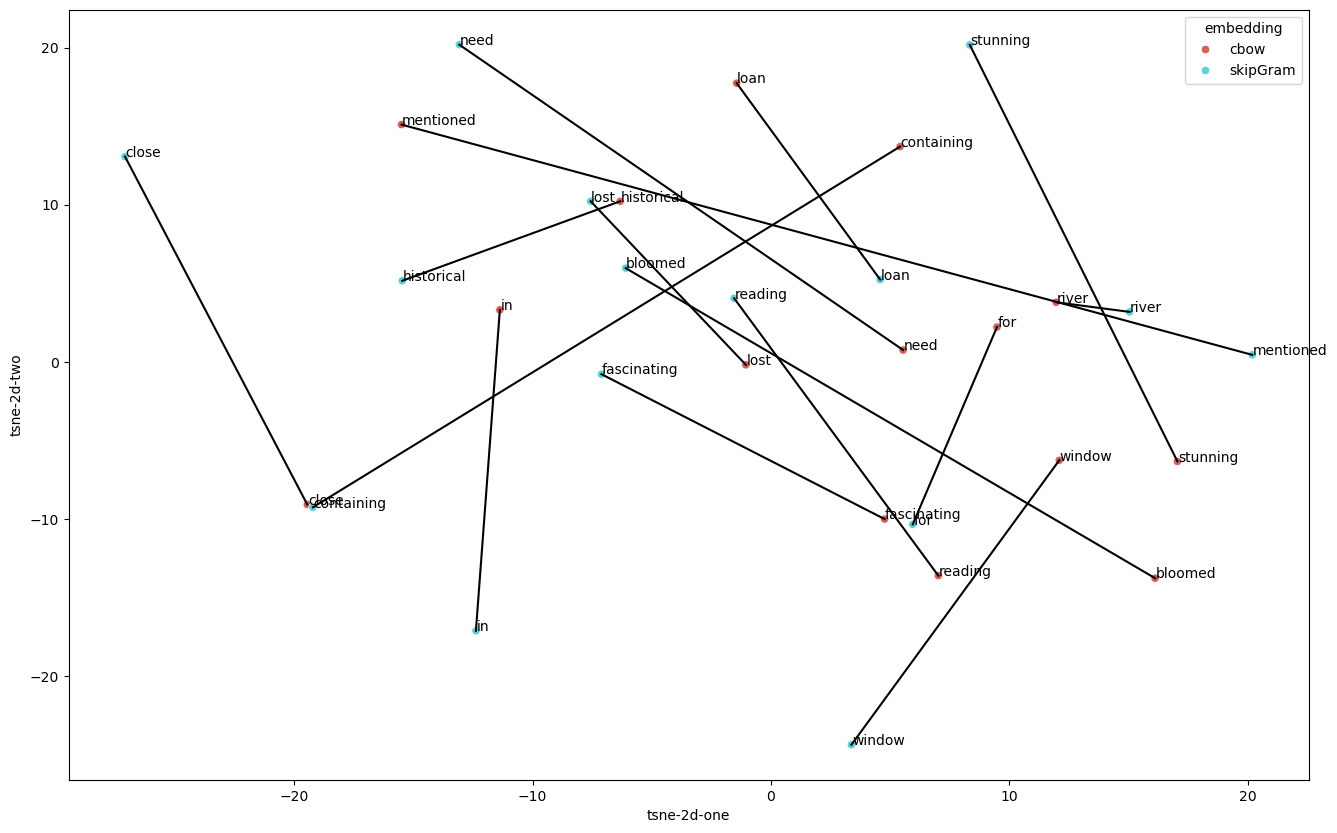

In [14]:
compare_embeddings([a,b])

## e. Can you find a text that 
Its embedding will be similar in these two algorithms?

```
It's the word "lead", since it appears multiple times in the corpus. 
It appears in different contexts though, so a simple embedding as word2vec puts them close
```

## f. Repeat step c with different window sizes. 
Is there a significant change?

### Skip-gram

In [15]:
import pandas as pd  # Import pandas to handle the DataFrame

window_sizes = [1, 2, 3, 4, 5]

# To hold embeddings for comparison and results
previous_embedding_dict = None
differences_data = []  # To store differences

for window_size in window_sizes:
    embedding_dict = train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, vocab_size, window_size=window_size)
    print(f"Window size: {window_size}\n")
    print("----------------------------------------\n")

    if previous_embedding_dict is not None:
        row_data = {}  # Row data for the DataFrame

        for word in embedding_dict:
            if word in previous_embedding_dict:
                difference = embedding_dict[word] - previous_embedding_dict[word]
                row_data[word] = difference  # Store difference
            else:
                print(f"Word: {word} is new in the current embedding.\n")

        differences_data.append(row_data)  # Append the differences for this window size comparison
        print("----------------------------------------\n")

    previous_embedding_dict = embedding_dict  # Update for the next comparison

# Create a DataFrame from the differences data
comparison_labels = [f"{window_sizes[i]}-{window_sizes[i+1]}" for i in range(len(window_sizes)-1)]
differences_df = pd.DataFrame(differences_data, index=comparison_labels)
print("Differences DataFrame:")
differences_df

Training device: CPU
Epoch 1/10, Loss: 45.3487
Epoch 2/10, Loss: 38.7105
Epoch 3/10, Loss: 35.8278
Epoch 4/10, Loss: 32.6050
Epoch 5/10, Loss: 28.4417
Epoch 6/10, Loss: 27.4497
Epoch 7/10, Loss: 22.1493
Epoch 8/10, Loss: 22.1676
Epoch 9/10, Loss: 18.6857
Epoch 10/10, Loss: 19.1688
Window size: 1

----------------------------------------

Training device: CPU
Epoch 1/10, Loss: 77.1162
Epoch 2/10, Loss: 66.3289
Epoch 3/10, Loss: 60.1772
Epoch 4/10, Loss: 51.9853
Epoch 5/10, Loss: 44.3000
Epoch 6/10, Loss: 39.5699
Epoch 7/10, Loss: 37.2892
Epoch 8/10, Loss: 32.5368
Epoch 9/10, Loss: 30.1921
Epoch 10/10, Loss: 26.0143
Window size: 2

----------------------------------------

----------------------------------------

Training device: CPU
Epoch 1/10, Loss: 93.4932
Epoch 2/10, Loss: 78.4470
Epoch 3/10, Loss: 67.8032
Epoch 4/10, Loss: 59.7814
Epoch 5/10, Loss: 53.1938
Epoch 6/10, Loss: 47.5596
Epoch 7/10, Loss: 42.8495
Epoch 8/10, Loss: 38.6642
Epoch 9/10, Loss: 35.1095
Epoch 10/10, Loss: 31.9

,mentioned,for,need,stunning,loan,reading,window,river,fascinating,in,...,report,manager,exposure,documents,garden,book,file,beautifully,.,approved
1-2,"[2.6404283, -2.9146752, -0.121591404, 0.133823...","[-0.4111924, -0.25033823, -0.46282518, 2.86224...","[-1.4424261, -0.06892127, 0.31341234, -1.73204...","[0.9881461, 0.6450664, -1.970771, 0.32521617, ...","[-0.9095906, -0.7172562, 1.2394139, 0.44439274...","[0.0065737665, 0.74368, 0.21082121, 0.14840633...","[2.35373, -0.7617941, 1.9580705, 0.3816022, 2....","[-1.6061251, 2.795342, -0.07987043, 2.0675166,...","[-1.8032267, -1.6932971, -0.806351, 2.602399, ...","[0.36419138, 3.884799, -0.18035352, -0.1560568...",...,"[-0.4095617, 1.240093, -0.54909885, -1.3132337...","[0.394118, -0.3359974, 0.73876494, -3.5103436,...","[-0.06567937, -0.61445314, -0.1955725, 1.01682...","[0.87855, 0.5286859, 2.207384, 1.0736645, -0.8...","[-2.700759, -0.40652055, -1.3474613, 0.0309129...","[0.6293543, 0.9992599, -0.8075509, 0.17840794,...","[-1.7557358, -0.260168, -0.040894687, 0.366093...","[-1.7269998, -1.5655663, -0.39325634, -0.17024...","[-1.541672, -0.6354708, -2.810412, 0.86855996,...","[-0.57092977, 0.25258896, 0.5568035, -0.624742..."
2-3,"[0.44633293, 2.3276837, -2.3106706, -1.1391878...","[0.47956312, -0.2994838, 1.5214059, -2.0683367...","[-0.6796253, -0.007400915, -0.5865659, 1.73045...","[-0.33586264, -0.53982264, 1.3234638, -1.56094...","[-0.2957502, -1.0719327, 0.97165173, 2.1807814...","[0.24763106, 0.53489447, -0.5006755, 0.7507597...","[-1.7690355, 1.0033579, -1.6141874, 0.07025948...","[-0.85441566, -1.6889168, -0.09766056, 0.19575...","[1.0054446, 0.04251033, -0.4147091, -3.2388682...","[-0.8639822, -1.479588, -0.19903429, -0.564486...",...,"[-0.3324342, -1.5516169, 1.6348412, 1.5838389,...","[-1.0256796, -0.9310308, -0.76322806, 2.486130...","[0.28575605, 0.68892854, 1.5834155, -1.2479339...","[-0.6266805, -1.2095776, -0.3052761, 0.5346981...","[0.6477544, 1.3263395, 2.0842667, -2.545945, 0...","[-1.4771897, -0.7549547, -0.2254476, -0.627703...","[0.50047815, -0.8949332, 0.9675913, -0.6853288...","[1.8020303, -0.28893435, -1.5743581, 0.5948509...","[1.2155833, -1.2274795, 0.6375461, -0.0252451,...","[2.0360746, 2.1630886, -0.3704654, -1.5161245,..."
3-4,"[0.5229665, 1.3960339, 3.3304749, 1.0140986, 1...","[-0.77681035, 1.2918179, -1.0915679, 1.1081555...","[1.3034204, 0.40278304, -0.24461341, -0.712654...","[-1.8115581, 0.007638693, 2.0754972, 1.304556,...","[0.18638194, 1.2357619, -0.70881027, -3.418632...","[-0.045995176, -0.15267384, 0.30839396, 0.3602...","[0.60723597, 0.5484773, 1.884629, -0.8607978, ...","[0.16147435, 0.5646212, 0.5723303, -0.5301904,...","[0.20847854, -0.22543234, 0.9996662, 0.1460882...","[1.9206281, 1.1088209, -0.20361713, -0.0638126...",...,"[0.014653355, 0.5341935, -0.061436057, -0.1739...","[0.82239014, 1.9846554, -0.40298182, -1.280036...","[0.7983326, 2.1079988, 0.09823239, -0.16654186...","[2.8672721, 0.5285144, -0.4316482, 0.32968074,...","[2.080918, -0.88048893, -2.411408, 2.8527253, ...","[1.4598424, -0.31443536, -0.35884622, -0.46124...","[0.766078, 0.7513131, 0.13224319, 0.890909, 0....","[-0.4058857, 1.2612747, 1.5589838, -0.7335726,...","[-0.13533491, 2.0840437, 0.8986613, -0.4691007...","[0.69636035, -3.145805, -0.8999059, 0.55026937..."
4-5,"[-0.5199723, -2.501027, -0.420259, 0.058101088...","[0.6072456, -0.76861966, 0.0516631, -0.6938182...","[0.10440395, -0.24104983, -0.2275998, 0.879839...","[2.5598998, -0.62907475, -3.940056, 0.47602496...","[1.388103, -1.0837721, -0.7844491, 1.9214586, ...","[0.068334304, -0.3655802, -0.23334277, -2.2124...","[0.07011387, -0.67782784, -0.5776571, 1.858385...","[-0.90882564, 0.25231063, -0.3887197, 1.446991...","[0.8401382, 1.4445286, -0.16457078, 2.4415364,...","[1.5191371, -1.3140941, 0.2253094, -0.00169903...",...,"[0.95154417, 1.4130301, -1.0523679, -2.5560353...","[-1.4704448, -1.1906036, -0.92144364, 0.933251...","[-2.6148102, -3.6245227, -2.18987, 0.8913374, ...","[-1.5972334, -2.5035715

We can see that there differences between different window sizes. However, it doesn't seem to have a constant trend. Increasing the window size is supposed to make the model be better at recognizing context, and thus the weights should change drastically for double-meaning words (such as bank) and we can see that it does.

In [16]:
skgm_embeddings = [train_skipgram_model(tokenized_corpus, word_to_index, index_to_word, 
                                    vocab_size, window_size=window_size) for window_size in [1,2,3,4,5]]

Training device: CPU
Epoch 1/10, Loss: 48.6721
Epoch 2/10, Loss: 44.1674
Epoch 3/10, Loss: 38.2659
Epoch 4/10, Loss: 35.6064
Epoch 5/10, Loss: 32.1308
Epoch 6/10, Loss: 30.0761
Epoch 7/10, Loss: 27.2084
Epoch 8/10, Loss: 25.6520
Epoch 9/10, Loss: 25.0848
Epoch 10/10, Loss: 20.6970
Training device: CPU
Epoch 1/10, Loss: 70.8862
Epoch 2/10, Loss: 58.5725
Epoch 3/10, Loss: 51.3413
Epoch 4/10, Loss: 47.1686
Epoch 5/10, Loss: 39.6594
Epoch 6/10, Loss: 36.0290
Epoch 7/10, Loss: 34.3275
Epoch 8/10, Loss: 29.3556
Epoch 9/10, Loss: 27.3510
Epoch 10/10, Loss: 25.5125
Training device: CPU
Epoch 1/10, Loss: 86.9946
Epoch 2/10, Loss: 72.7202
Epoch 3/10, Loss: 62.8425
Epoch 4/10, Loss: 55.1455
Epoch 5/10, Loss: 49.0276
Epoch 6/10, Loss: 43.8593
Epoch 7/10, Loss: 39.5072
Epoch 8/10, Loss: 35.8278
Epoch 9/10, Loss: 32.6149
Epoch 10/10, Loss: 29.8958
Training device: CPU
Epoch 1/10, Loss: 115.8763
Epoch 2/10, Loss: 92.4463
Epoch 3/10, Loss: 79.7233
Epoch 4/10, Loss: 67.4848
Epoch 5/10, Loss: 59.8109
Ep

In [17]:
skgmW1 = embedding_Tsne(skgm_embeddings[0], 'skipGram_w1')
skgmW3 = embedding_Tsne(skgm_embeddings[1], 'skipGram_w2')
skgmW5 = embedding_Tsne(skgm_embeddings[3], 'skipGram_w3')

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.995967
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.566994
[t-SNE] KL divergence after 300 iterations: 1.446503
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.964650
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.592598
[t-SNE] KL divergence after 300 iterations: 1.349888
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.836900
[t-SNE] KL divergence after 250 iterations with early 

/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [18]:
a = skgmW1.iloc[:15,:]
b = skgmW3.loc[a.index,:]
c = skgmW5.loc[a.index,:]

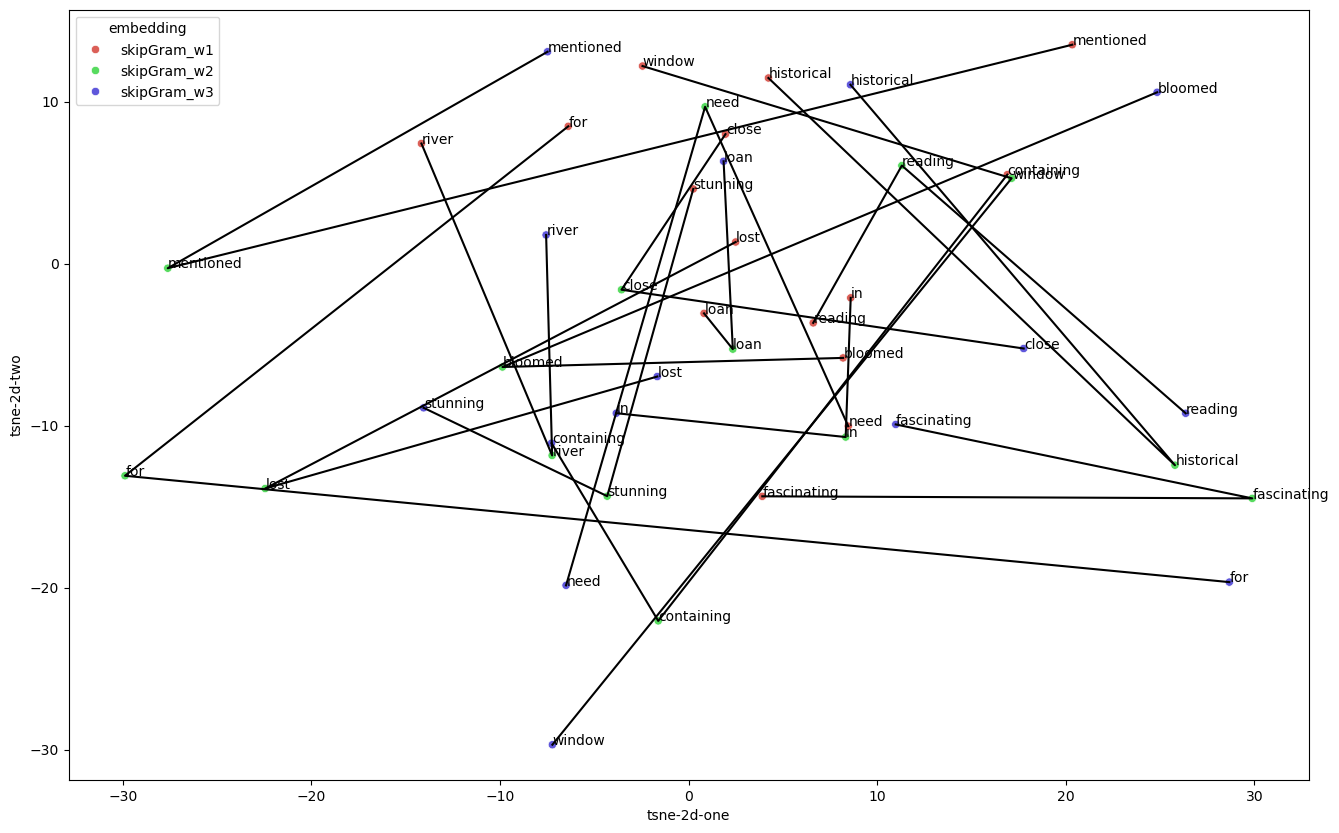

In [19]:
compare_embeddings([a,b,c])

### CBOW

In [20]:
cbow_embeddings = [train_cbow_model(tokenized_corpus, word_to_index, index_to_word, 
                                    vocab_size, window_size=window_size) for window_size in [1,2,3]]

Training device: CPU
Epoch 1/10, Loss: 7.9839
Epoch 2/10, Loss: 7.1565
Epoch 3/10, Loss: 6.7121
Epoch 4/10, Loss: 6.2361
Epoch 5/10, Loss: 5.7048
Epoch 6/10, Loss: 5.3319
Epoch 7/10, Loss: 4.8052
Epoch 8/10, Loss: 4.4056
Epoch 9/10, Loss: 4.0676
Epoch 10/10, Loss: 3.8214
Training device: CPU
Epoch 1/10, Loss: 8.0399
Epoch 2/10, Loss: 7.4724
Epoch 3/10, Loss: 7.1339
Epoch 4/10, Loss: 6.7619
Epoch 5/10, Loss: 6.2675
Epoch 6/10, Loss: 5.9708
Epoch 7/10, Loss: 5.6917
Epoch 8/10, Loss: 5.3645
Epoch 9/10, Loss: 5.0371
Epoch 10/10, Loss: 4.8602
Training device: CPU
Epoch 1/10, Loss: 7.9494
Epoch 2/10, Loss: 7.4824
Epoch 3/10, Loss: 7.1951
Epoch 4/10, Loss: 6.8541
Epoch 5/10, Loss: 6.6023
Epoch 6/10, Loss: 6.3261
Epoch 7/10, Loss: 6.1306
Epoch 8/10, Loss: 5.8881
Epoch 9/10, Loss: 5.6529
Epoch 10/10, Loss: 5.3563


In [21]:
cbowW1 = embedding_Tsne(cbow_embeddings[0], 'cbow_w1')
cbowW2 = embedding_Tsne(cbow_embeddings[1], 'cbow_w2')
cbowW3 = embedding_Tsne(cbow_embeddings[2], 'cbow_w3')

[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 2.136676
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.614571
[t-SNE] KL divergence after 300 iterations: 1.606920
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 1.977246
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.735882
[t-SNE] KL divergence after 300 iterations: 1.214298
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 50 samples in 0.000s...
[t-SNE] Computed neighbors for 50 samples in 0.003s...
[t-SNE] Computed conditional probabilities for sample 50 / 50
[t-SNE] Mean sigma: 2.003774
[t-SNE] KL divergence after 250 iterations with early 

/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/media/michael/Data/anaconda3/envs/NLP/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [22]:
a = cbowW1.iloc[:15,:]
b = cbowW2.loc[a.index,:]
c = cbowW3.loc[a.index,:]

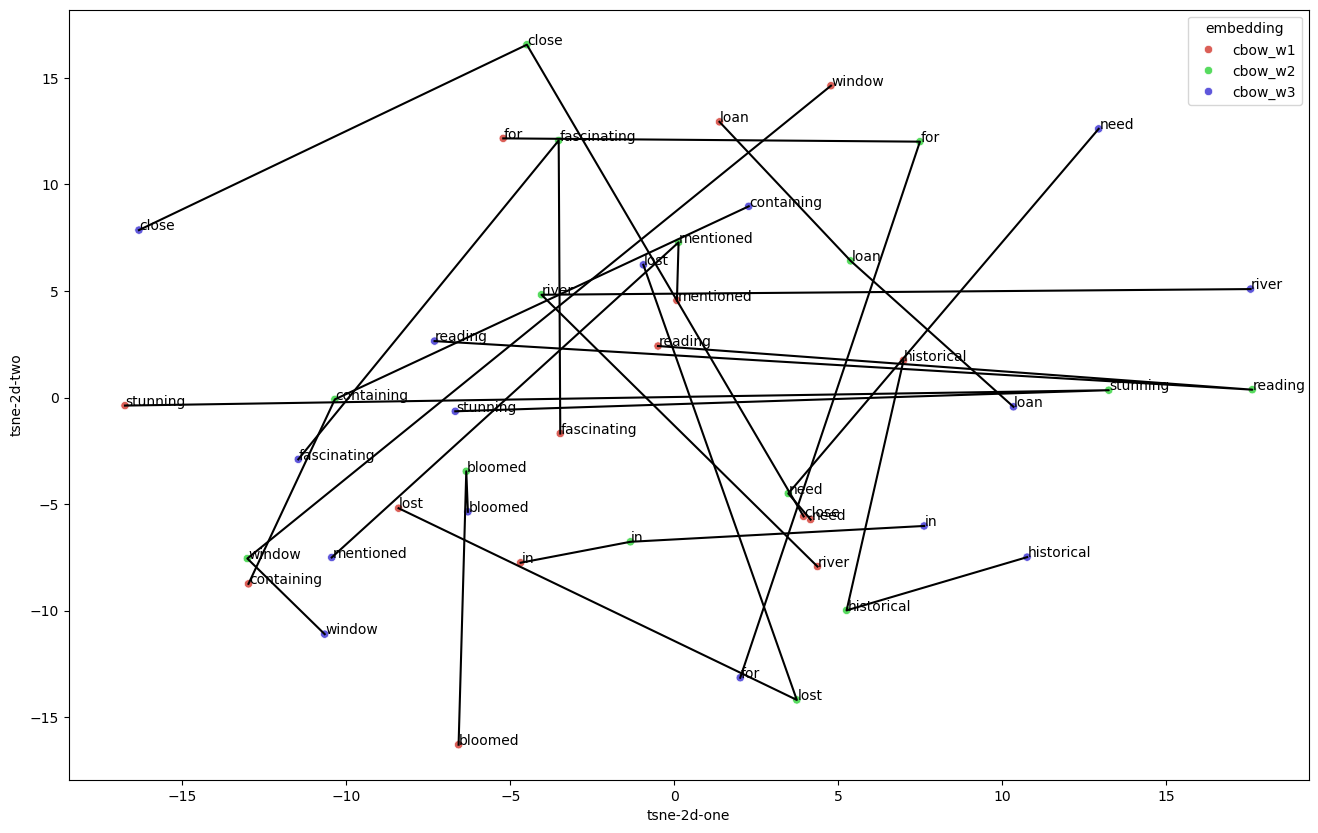

In [23]:
compare_embeddings([a,b,c])

## g. Compare these two models 
In terms of capturing the syntactic and the semantic relationship between words.

```
We think that with such small corpus as we were given, 
it will not be possible to see any difference in 
syntactic or the semantic relationship between words.
```

## h. Demonstrate the difference between CBOW and Skip-grams
In terms of cosine similarity between the following words:
 - bank, rose, lead, book and file.

### Skip-gram

In [24]:
import pandas as pd
from scipy.spatial.distance import cosine

selected_words = ['bank', 'rose', 'lead', 'book', 'file']  # Words to calculate cosine similarity for

# Initialize an empty DataFrame to store cosine similarities
cosine_similarity_df = pd.DataFrame(index=selected_words, columns=selected_words)

# Calculate cosine similarity for selected word pairs
for word1 in selected_words:
    for word2 in selected_words:
        if word1 != word2:
            # Calculate cosine similarity (1 - cosine distance)
            similarity = 1 - cosine(embedding_dict_skipgram[word1], embedding_dict_skipgram[word2])
            cosine_similarity_df.at[word1, word2] = similarity
        else:
            # Similarity with itself is 1
            cosine_similarity_df.at[word1, word2] = 1.0

# Convert to float type (optional)
cosine_similarity_df = cosine_similarity_df.astype(float)

# Display the resulting DataFrame
cosine_similarity_df

,bank,rose,lead,book,file
bank,1.000000,-0.059051,0.234064,-0.011793,-0.055539
rose,-0.059051,1.000000,-0.060203,-0.030835,-0.072909
lead,0.234064,-0.060203,1.000000,0.162137,-0.057553
book,-0.011793,-0.030835,0.162137,1.000000,0.154223
file,-0.055539,-0.072909,-0.057553,0.154223,1.000000


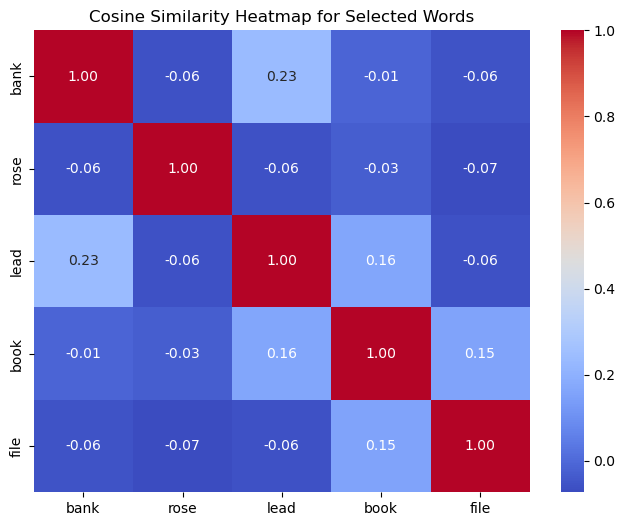

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cosine_similarity_df, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title to the heatmap
plt.title("Cosine Similarity Heatmap for Selected Words")
plt.show()

### CBOW

In [26]:
import pandas as pd
from scipy.spatial.distance import cosine

selected_words = ['bank', 'rose', 'lead', 'book', 'file']  # Words to calculate cosine similarity for

# Initialize an empty DataFrame to store cosine similarities
cosine_similarity_df = pd.DataFrame(index=selected_words, columns=selected_words)

# Calculate cosine similarity for selected word pairs
for word1 in selected_words:
    for word2 in selected_words:
        if word1 != word2:
            # Calculate cosine similarity (1 - cosine distance)
            similarity = 1 - cosine(embedding_dict_cbow[word1], embedding_dict_cbow[word2])
            cosine_similarity_df.at[word1, word2] = similarity
        else:
            # Similarity with itself is 1
            cosine_similarity_df.at[word1, word2] = 1.0

# Convert to float type (optional)
cosine_similarity_df = cosine_similarity_df.astype(float)

# Display the resulting DataFrame
cosine_similarity_df

,bank,rose,lead,book,file
bank,1.000000,0.085598,0.034745,0.192697,0.004749
rose,0.085598,1.000000,0.135218,-0.042071,-0.120726
lead,0.034745,0.135218,1.000000,0.244165,-0.157476
book,0.192697,-0.042071,0.244165,1.000000,0.021747
file,0.004749,-0.120726,-0.157476,0.021747,1.000000


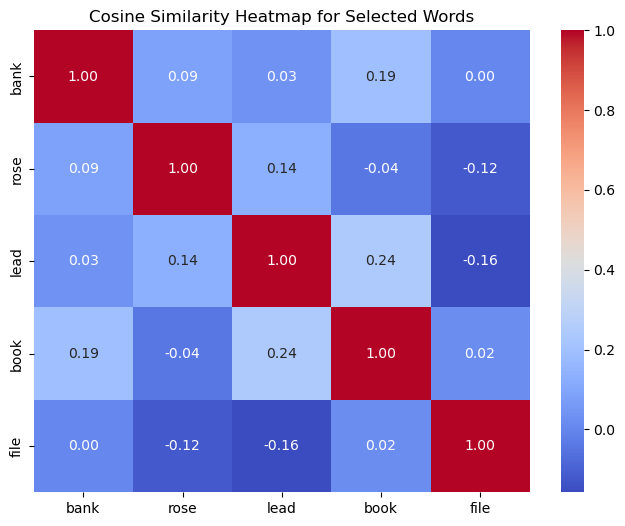

In [27]:
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cosine_similarity_df, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title to the heatmap
plt.title("Cosine Similarity Heatmap for Selected Words")
plt.show()

## i. How can the subword embeddings be applied?
Michael

# 2. Create example sentences demonstrating: 
how contextual embeddings handle words with multiple meanings (polysemy) differently than static embeddings like Word2Vec.
Barak

In [28]:
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import nltk
from nltk.tokenize import word_tokenize

# Make sure to download NLTK data (if not already downloaded)
nltk.download('punkt')

# Load ELMo model from TensorFlow Hub
elmo = hub.load("https://tfhub.dev/google/elmo/3")

# Example sentences for demonstrating polysemy
example_sentences = [
    "He went to the bank to deposit some money.",  # bank as a financial institution
    "The fisherman docked his boat near the river bank.",  # bank as a riverbank
    "She rose from her chair to make an announcement.",  # rose as an action/past tense of rise
    "The rose smelled fragrant and bloomed beautifully.",  # rose as a flower
    "The project manager will lead the team during the meeting.",  # lead as to guide
    "Exposure to lead in paint can cause health issues."  # lead as a toxic substance
]

words_to_compare = ["bank", "rose", "lead"]  # Words to compare

# Function to get contextual embeddings using ELMo
def get_elmo_embeddings(sentences, word):
    """
    Extract contextual embeddings for a specific word from ELMo.
    Arguments:
    - sentences: List of sentences to process.
    - word: The target word to extract embeddings for.

    Returns:
    - A dictionary where keys are sentences and values are embeddings of the target word.
    """
    embeddings = {}

    for sentence in sentences:
        elmo_embeddings = elmo.signatures["default"](tf.constant([sentence]))["elmo"]  # Shape: (1, sentence_length, 1024)
        elmo_embeddings_np = elmo_embeddings.numpy().squeeze()  # Shape: (sentence_length, 1024)
        tokens = word_tokenize(sentence)  # Tokenize using nltk
        if word in tokens:
            word_index = tokens.index(word)  # Find the index of the word
            embeddings[sentence] = elmo_embeddings_np[word_index]  # Extract the embedding for the word
        else:
            embeddings[sentence] = None  # Word not found in the sentence
    return embeddings

# Get static embeddings from the Skip-gram Word2Vec model
def get_skipgram_embedding(word, embedding_dict_skipgram):
    """
    Extract the static embedding for a word from the Skip-gram Word2Vec model.
    """
    return embedding_dict_skipgram.get(word)

# Compare Skip-gram and ELMo embeddings
for word in words_to_compare:
    print(f"\nWord: '{word}'")

    # Contextual embeddings with ELMo
    print("Contextual Embeddings (varies by sentence):")
    elmo_embeddings = get_elmo_embeddings(example_sentences, word)
    for sentence, embedding in elmo_embeddings.items():
        if embedding is not None:
            print(f"  Sentence: {sentence}")
            print(f"    Embedding: {embedding[:5]}...")  # Print only the first 5 dimensions for brevity
        else:
            print(f"  Sentence: {sentence}")
            print("    Embedding: Word not found in the sentence.")

    # Static embedding using Skip-gram Word2Vec
    print("Static Embedding (same for all sentences):")
    skipgram_embedding = get_skipgram_embedding(word, embedding_dict_skipgram)
    if skipgram_embedding is not None:
        print(f"  Embedding: {skipgram_embedding[:5]}...")  # Print only the first 5 dimensions for brevity
    else:
        print("  Embedding: Word not found in the Word2Vec vocabulary.")

2025-01-10 00:23:56.813953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-10 00:23:56.824453: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-10 00:23:56.829618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736461436.840364 1269316 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736461436.843782 1269316 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regist


Word: 'bank'
Contextual Embeddings (varies by sentence):
  Sentence: He went to the bank to deposit some money.
    Embedding: [-0.40484866  0.18932015  0.08645026  0.26849568  0.3523057 ]...
  Sentence: The fisherman docked his boat near the river bank.
    Embedding: [ 0.10449292  0.31060845 -0.5630889  -0.5370658  -0.8182452 ]...
  Sentence: She rose from her chair to make an announcement.
    Embedding: Word not found in the sentence.
  Sentence: The rose smelled fragrant and bloomed beautifully.
    Embedding: Word not found in the sentence.
  Sentence: The project manager will lead the team during the meeting.
    Embedding: Word not found in the sentence.
  Sentence: Exposure to lead in paint can cause health issues.
    Embedding: Word not found in the sentence.
Static Embedding (same for all sentences):
  Embedding: [ 0.17544198 -1.3886334  -0.43731153 -0.43254906  0.4844587 ]...

Word: 'rose'
Contextual Embeddings (varies by sentence):
  Sentence: He went to the bank to depo

# 3. Propose metrics
For evaluating word embeddings that can differentiate between syntactic and semantic relationships.
Michael

To evaluate word embeddings for syntactic and semantic relationships, you can use distinct metrics tailored to each type of relationship:

1. **Semantic Similarity**: Use cosine similarity on word pairs with known semantic relations, such as those in the WordSim-353 or MEN datasets, and evaluate the correlation with human judgments.

2. **Syntactic Analogy Tasks**: Employ analogy benchmarks like "king - man + woman = queen" to measure syntactic consistency, as in the Google Analogy dataset.

3. **Clustering**: Group words with similar meanings (e.g., synonyms) or syntactic roles (e.g., verbs vs. nouns) and evaluate clustering quality using metrics like purity or silhouette scores.

4. **Downstream Task Performance**: Test embeddings on tasks like POS tagging for syntactic relevance or text classification for semantic richness.

5. **Contextual Integrity**: Use probing classifiers to assess how well syntactic and semantic properties are encoded in the embeddings.

Each metric emphasizes different aspects, helping to differentiate between syntactic and semantic properties in embeddings.

# 4. Use the Gensim library 
To train a Word2Vec model on a custom corpus.  
Barak

In [29]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from nltk.tokenize import word_tokenize, sent_tokenize
import nltk

# Ensure NLTK dependencies are downloaded
nltk.download('punkt')

class EpochLogger(CallbackAny2Vec):
    """Callback to log information about training progress."""
    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print(f"Epoch {self.epoch} starting...")

    def on_epoch_end(self, model):
        print(f"Epoch {self.epoch} finished.")
        self.epoch += 1

def train_word2vec(corpus, size=100, window=5, min_count=1, sg=1, epochs=10, workers=4):
    """
    Generalized function to train a Word2Vec model using Gensim, with sentence tokenization
    using NLTK's tokenizer.

    Args:
        corpus (list of str): A list of sentences to train the model on.
        size (int): Dimensionality of the Word2Vec embeddings. Default is 100.
        window (int): Maximum distance between the current and predicted word within a sentence. Default is 5.
        min_count (int): Ignore words with total frequency lower than this. Default is 1.
        sg (int): 1 for skip-gram; 0 for CBOW. Default is 1 (skip-gram).
        epochs (int): Number of training epochs. Default is 10.
        workers (int): Number of threads to use during model training. Default is 4.

    Returns:
        Word2Vec: Trained Word2Vec model.
    """
    # Tokenize each sentence using NLTK
    tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

    # Instantiate the logger for monitoring progress
    epoch_logger = EpochLogger()

    # Initialize and train the Word2Vec model
    model = Word2Vec(
        sentences=tokenized_corpus,
        vector_size=size,
        window=window,
        min_count=min_count,
        sg=sg,
        epochs=epochs,
        workers=workers,
        callbacks=[epoch_logger]
    )
    print("Model training completed.")
    return model

[nltk_data] Downloading package punkt to /home/michael/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## a. Evaluate the quality of embeddings 
By calculating the cosine similarity for the following word pairs:
```
i. "king" and "queen"  
ii. "man" and "woman"
iii. "apple" and "orange"
```

In [30]:

# Define a logical sentence containing the specified words
corpus = ["The king and the queen ruled the land, while the man and the woman tended to the apple orchard near the orange grove."]

# Train a Word2Vec model on the corpus
model = train_word2vec(corpus=corpus, size=100, window=5, min_count=1, sg=1, epochs=10, workers=4)

# Extract embeddings for the specified words
embedding_dict = {word: model.wv[word] for word in ["king", "queen", "man", "woman", "apple", "orange"]}

# Define the words for cosine similarity calculation
selected_words = ["king", "queen", "man", "woman", "apple", "orange"]

# Initialize a DataFrame to store cosine similarities
cosine_similarity_df = pd.DataFrame(index=selected_words, columns=selected_words)

# Calculate cosine similarity for each word pair
from scipy.spatial.distance import cosine

for word1 in selected_words:
    for word2 in selected_words:
        if word1 != word2:
            # Calculate cosine similarity
            similarity = 1 - cosine(embedding_dict[word1], embedding_dict[word2])
            cosine_similarity_df.at[word1, word2] = similarity
        else:
            # Set self-similarity to 1
            cosine_similarity_df.at[word1, word2] = 1.0

# Convert to float type (optional for better display purposes)
cosine_similarity_df = cosine_similarity_df.astype(float)

# Display the resulting DataFrame of cosine similarities
cosine_similarity_df

Epoch 0 starting...
Epoch 0 finished.
Epoch 1 starting...
Epoch 1 finished.
Epoch 2 starting...
Epoch 2 finished.
Epoch 3 starting...
Epoch 3 finished.
Epoch 4 starting...
Epoch 4 finished.
Epoch 5 starting...
Epoch 5 finished.
Epoch 6 starting...
Epoch 6 finished.
Epoch 7 starting...
Epoch 7 finished.
Epoch 8 starting...
Epoch 8 finished.
Epoch 9 starting...
Epoch 9 finished.
Model training completed.


,king,queen,man,woman,apple,orange
king,1.000000,-0.044282,0.041448,0.015665,0.007389,-0.260190
queen,-0.044282,1.000000,-0.028988,-0.255465,0.253951,0.109047
man,0.041448,-0.028988,1.000000,0.096001,0.116301,-0.148974
woman,0.015665,-0.255465,0.096001,1.000000,0.004475,-0.010320
apple,0.007389,0.253951,0.116301,0.004475,1.000000,-0.031320
orange,-0.260190,0.109047,-0.148974,-0.010320,-0.031320,1.000000


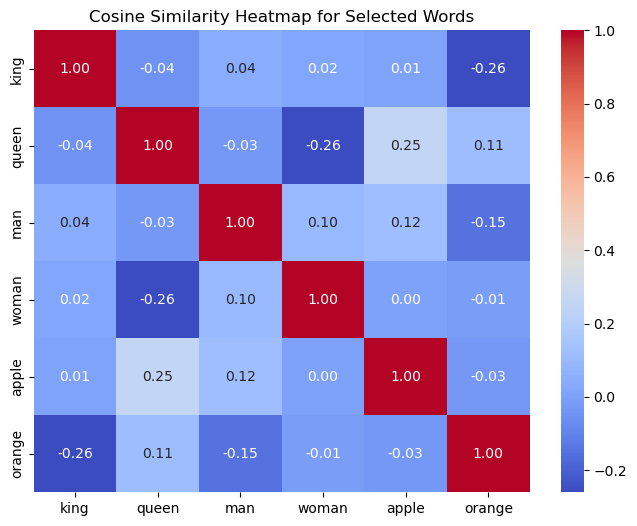

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cosine_similarity_df, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title to the heatmap
plt.title("Cosine Similarity Heatmap for Selected Words")
plt.show()

## b. Write a brief explanation of the results.

We can see that the word couples: "king" and "queen", "man" and "woman", "apple" and "orange" may have a similar context, but have a pretty weak cosine similarity when it comes to a Word2vec model. It could mean that a Word2Vec model looks at the words independently and thus words with similar context might not necessarily have a strong cosine similarity, or it could be that the embedding captures another similarity.

# 5. Train the GloVe model 
Using the glove-python package on a subset of a publicly available dataset (e.g., Wikipedia, or a smaller custom corpus).

Michael

The [glove-python](https://github.com/maciejkula/glove-python) package has not been maintained for more than 10 years. It is not compatible with modern versions of python. We tried to find alternatives on the internet, but were unsuccessful. 

## a. Use t-SNE or PCA 
To visualize the embeddings in 2D.

## b. Analyze the clustering patterns observed in the visualization.